<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="cognitiveclass.ai logo"  />
</center>


# **Variational Autoencoders**


Variational Autoencoders are a type of deep learning generative model. Once you train them on sufficiently large datasets and let them learn latent representations of the data, they can be used to draw faces, plot digits, produce music, and generate anything you can think of.
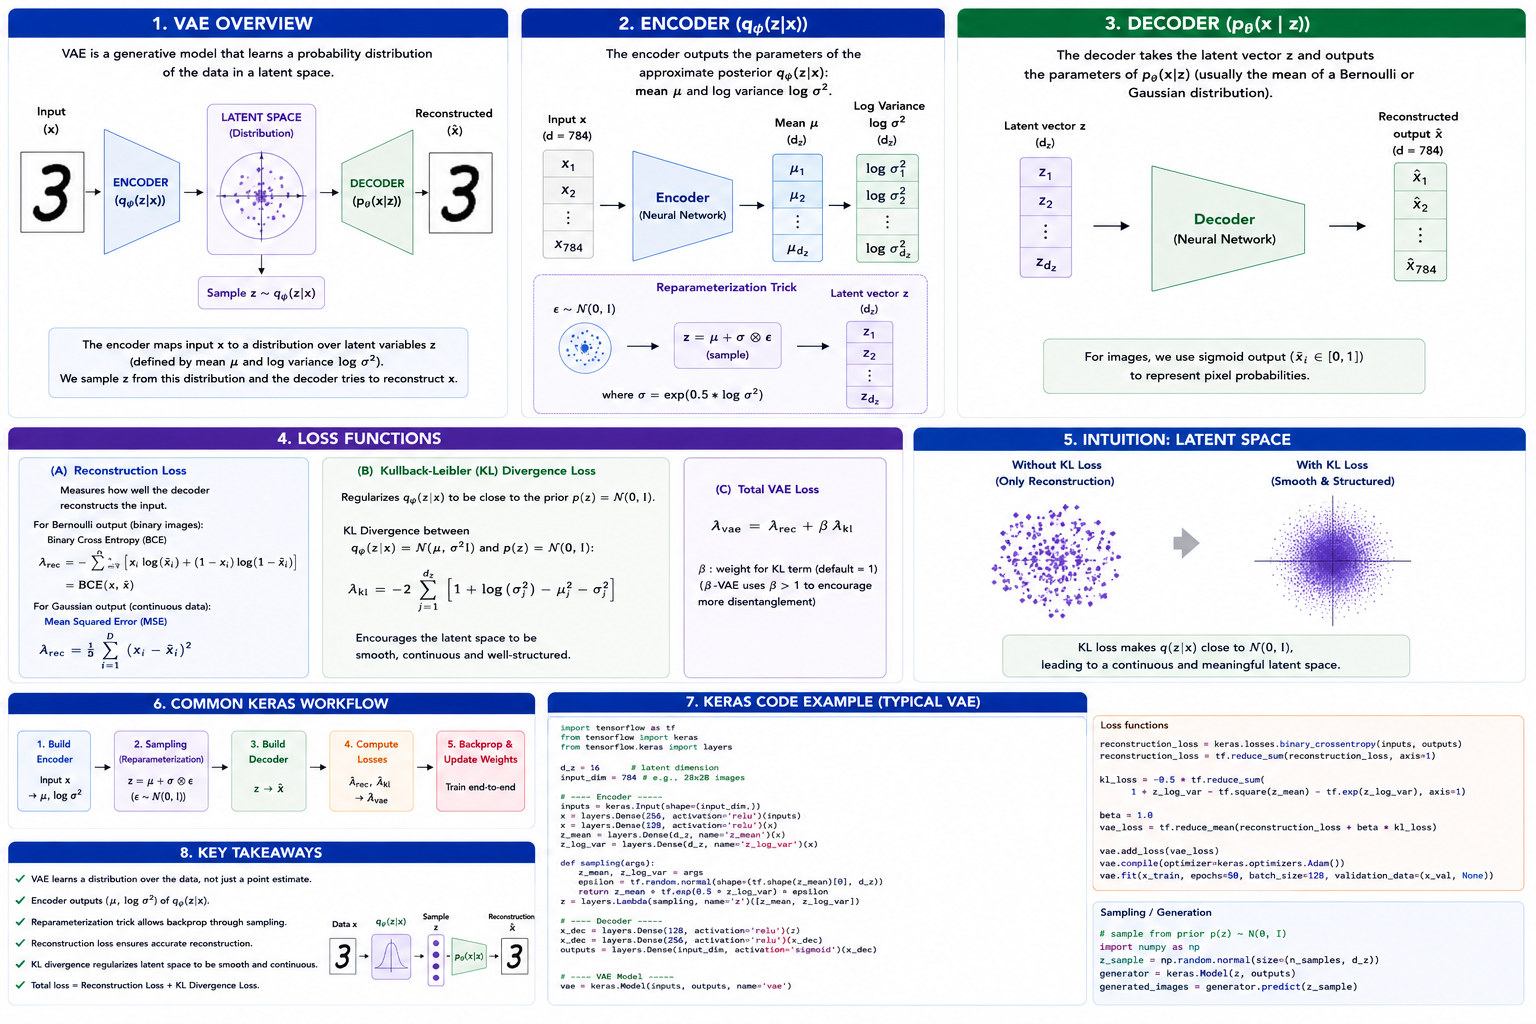

In this lab, we will study the architecture of VAEs. We will build a VAE ourselves using Keras and train the model on the MNIST digits dataset, so that they can be used to generate new images of digits.


## **Table of Contents**

1. [Objectives](#Objectives)
2. [Setup](#Setup)
    1. [Installing Required Libraries](#Installing-Required-Libraries)
    2. [Importing Required Libraries](#Importing-Required-Libraries)
    3. [Defining Helper Functions](#Defining-Helper-Functions)
3. [Prepare Dataset](#Preparing-the-Dataset)
4. [Variational Autoencoder](#Variational-Autoencoder)
    1. [VAE Workflow](#VAE-Workflow)
5. [Encoder Part](#Encoder-Part)
6. [Decoder Part](#Decoder-Part)
7. [Loss Function](#Loss-Function)
    1. [Reconstruction Loss](#Reconstruction-Loss)
    2. [Kullback-Leibler (KL) Divergence Loss](#Kullback-Leibler-KL-Divergence-Loss)
    3. [Total Loss](#Total-Loss)
    4. [Implementation Details](#Implementation-Details)
8. [Putting it all together](#Putting-it-all-Together)
9. [Training the VAE](#Training-the-VAE)
10. [Modified Version](#Modified-Version)


<a id="Objectives"></a>
## **Objectives**

After completing this lab you will be able to:

*   Understand the architecture of a Variational Autoencoder
*   Build and train Variational Autoencoder in Keras


***


<a id="Setup"></a>
## **Setup**


For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


<a id="Installing-Required-Libraries"></a>
### **Installing Required Libraries**

The following required libraries are pre-installed in the Skills Network Labs environment. However, if you run these notebook commands in a different Jupyter environment (like Watson Studio or Ananconda), you will need to install these libraries by removing the `#` sign before `!mamba` in the code cell below.


In [181]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1
# Note: If your environment doesn't support "!mamba install", use "!pip install"

Run the following upgrade and then **RESTART YOUR KERNEL**. Make sure the version of tensorflow imported below is **no less than 2.9.0**.


In [182]:
# %%capture
#!pip3 install --upgrade tensorflow

<a id="Importing-Required-Libraries"></a>
### **Importing Required Libraries**

*We recommend you import all required libraries in one place (here):*


In [183]:
# You can use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass


import warnings

warnings.warn = warn
warnings.filterwarnings("ignore")

import os
import numpy as np

# Import the keras library
import tensorflow as tf

print(tf.__version__)
tf.config.set_visible_devices([], "GPU")
from tensorflow import keras
from tensorflow.keras import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Layer,
    Reshape,
    Conv2DTranspose,
)
from tensorflow.python.client import device_lib
from keras.layers import Multiply, Add
from keras import backend as K

from numpy import random

from matplotlib import pyplot as plt

2.20.0


<a id="Defining-Helper-Functions"></a>
### **Defining Helper Functions**


In [184]:
def plot_label_clusters(model, data, labels):
    # display a 2D plot of the digit classes in the latent space
    z_mean, _, _ = encoder.predict(data)
    plt.figure(figsize=(8, 6))
    plt.scatter(z_mean[:, 0], z_mean[:, 1], c=labels)
    plt.colorbar()
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.show()

<a id="Preparing-the-Dataset"></a>
## **Preparing the Dataset**


We load the MNIST handwritten digit dataset:


In [185]:
# Import data
(X_train, y_train), (_, _) = keras.datasets.mnist.load_data()

There are 60000 $28 \times 28$ images in the training set:


In [186]:
X_train.shape, y_train.shape

((60000, 28, 28), (60000,))

Let's look at the unique labels of the digits that we want to predict:


In [187]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

We will reshape the training set to $60000 \times 28 \times 28 \times 1$ to work with convolutions. 1 indicates that the input images only have one channel, that is: grayscale images.


In [188]:
print(f"Before reshaping, X_train has a shape of: {X_train.shape}")

X_train = X_train.reshape(
    (X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
)
print(f"After reshaping, X_train has a shape of: {X_train.shape}")

Before reshaping, X_train has a shape of: (60000, 28, 28)
After reshaping, X_train has a shape of: (60000, 28, 28, 1)


We cast the data type of `X_train` to `tf.float32` and normalize its values to range from 0 to 1:


In [189]:
X_train = tf.cast(X_train, tf.float32)
X_train = X_train / 255.0

We convert the tensors to a `tf.data.Dataset` object.


In [190]:
dataset = tf.data.Dataset.from_tensor_slices(X_train)
dataset

<_TensorSliceDataset element_spec=TensorSpec(shape=(28, 28, 1), dtype=tf.float32, name=None)>

We can plot five random samples from the training set:


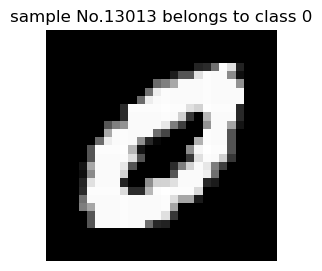

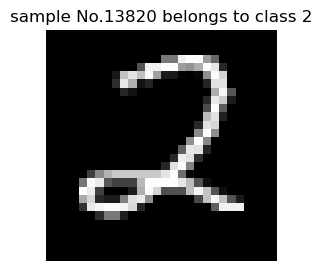

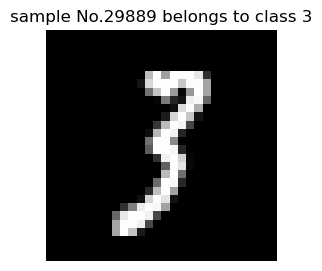

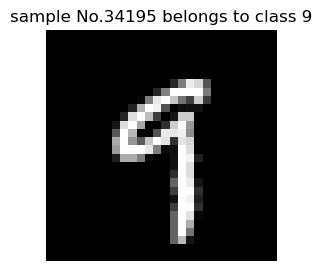

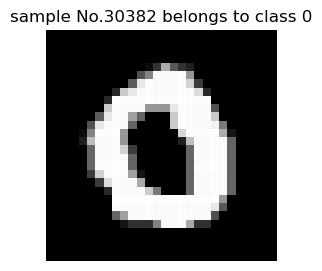

In [191]:
for r in random.randint(0, 59999, size=5, dtype=int):

    plt.figure(figsize=(3, 3))
    plt.imshow(X_train[r, :, :, 0], cmap="gray")
    plt.title("sample No.{} belongs to class {}".format(r, y_train[r]))
    plt.axis("off")

<a id="Variational-Autoencoder"></a>
## **Variational Autoencoder**

A Variational Autoencoder, or VAE, is a neural network that learns how to recreate data and also learns a useful space for generating new data.

Like a regular autoencoder, a VAE has two main parts: an encoder and a decoder.

* The encoder takes an input image $\boldsymbol{X}$ and compresses it into a smaller representation called the latent space.
* The decoder takes a point from the latent space and tries to rebuild the original image. The rebuilt image is written as $\boldsymbol{\hat X}$.

During training, the model compares the original image $\boldsymbol{X}$ with the reconstructed image $\boldsymbol{\hat X}$. The goal is to make the reconstruction close to the original.

**The important difference is how the VAE stores information in the latent space. A regular autoencoder usually maps each input to one fixed point. A VAE maps each input to a small probability distribution instead.**

In this lab, the encoder learns two values for each input: the mean and the log variance. These values describe a normal distribution in the latent space. We then sample a random point from that distribution and pass it to the decoder.

In the diagram, the letter $\boldsymbol z$ means a latent representation. A latent representation is the compressed information that the model learns from the input. The labels $\boldsymbol z^1$, $\boldsymbol z^2$, $\boldsymbol z^3$, and so on show different stages as information moves through the network. The most important one is $\boldsymbol z^5$: this is the sampled latent point that goes into the decoder. It is calculated from the learned mean, the learned standard deviation, and random noise $\boldsymbol{\epsilon}$.

This extra randomness helps the latent space become smoother and better organized. That is useful because we can later sample new points from the latent space and ask the decoder to generate new images.

In the following sections, we will build each part of the VAE shown in the diagram below.


 <center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/autoencoder.png"" width="800" alt="computer components"  />
<center>


<a id="VAE-Workflow"></a>
### **VAE Workflow**

The VAE workflow has five main steps:

1. **Input image**: Start with an image $\boldsymbol X$, such as a handwritten digit.
2. **Encode the image**: The encoder compresses $\boldsymbol X$ into a smaller latent representation.
3. **Learn a distribution**: Instead of producing one fixed latent point, the encoder produces `mean` and `log_var`. These two values describe a normal distribution in the latent space.
4. **Sample latent point**: The model samples $\boldsymbol z$ from that distribution using random noise $\boldsymbol{\epsilon}$. This is the reparameterization step.
5. **Decode the sample**: The decoder takes $\boldsymbol z$ and tries to reconstruct the original image as $\boldsymbol{\hat X}$.

During training, the VAE learns from two signals:

* The **reconstruction loss** teaches the decoder to rebuild the input image accurately.
* The **KL loss** teaches the encoder to keep the latent distribution close to a standard normal distribution.

After training, we can sample new random points from the latent space and pass them to the decoder to generate new images.


<a id="Encoder-Part"></a>
## **Encoder Part**

The encoder is the part of the VAE that reads the input image and turns it into information the decoder can use.

A VAE does not require a convolutional encoder. Any neural network that can compress the input into a latent representation can be used as the encoder. For example, you could use Dense layers for simple tabular data, recurrent layers for sequence data, or convolution layers for image data.

In this lab, the input data is made of images, so the encoder uses **convolution layers**. Convolution layers are a good choice for images because they can learn local visual patterns such as edges, curves, and small shapes.

We build the encoder in three steps:

* First, convolution layers extract useful image features and compress the image.
* Second, Dense layers use those features to learn the mean and log variance of a normal distribution in the latent space.
* Third, the model samples one latent point from that distribution. This sampled point is passed to the decoder.

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/encoder.png" width="30%" alt="computer components"/></center>


Here is the code for the first step of the encoder. The image passes through two convolution layers, then it is flattened and passed through a Dense layer. The result is stored in `encoder_output`. In the diagram, this stage is shown as $\boldsymbol z^2$.


In [192]:
encoder_input = keras.Input(shape=(28, 28, 1))
x = Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_input)
x = Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = Flatten()(x)
encoder_output = Dense(16, activation="relu")(x)

The second step turns `encoder_output` into a distribution in the latent space.

Instead of producing one fixed latent point, the encoder learns the parameters of a normal distribution. In this lab, it learns the **mean** and the **log variance**. These two values tell the model where the distribution is centered and how spread out it is.


 <center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/mean_var.png" width="400" alt="computer components"  />
<center>


To implement this step, we create **two Dense layers** in parallel:

* One Dense layer learns the **mean**.
* The other Dense layer learns the **log variance**.

We learn log variance instead of variance because it is usually more stable during training. Later, we can convert log variance into standard deviation using the exponential function.


In [193]:
latent_dim = 2

# Dense layer to learn the mean
mean = Dense(latent_dim, name="mean")(encoder_output)
# Dense layer to learn the log variance
log_var = Dense(latent_dim, name="z_log_var")(encoder_output)

# sigmia is calculated from log variance
# sigma = tf.exp(0.5 * log_var)
from tensorflow.keras.layers import Lambda

# Wrap the exponentiation in a Lambda layer to handle the KerasTensor
sigma = Lambda(lambda x: tf.exp(0.5 * x))(log_var)

The third step samples one point from the learned latent distribution. This sampled point is called $\boldsymbol z$. The decoder will use $\boldsymbol z$ to reconstruct the image or generate a new image.

The following diagram illustrates the random sampling:

<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/repramateriztion.png" width="400" alt="computer components"  />
<center> 


The sampled point, denoted by $\boldsymbol z^5$ in the diagram, comes from a normal distribution with mean $\boldsymbol{\mu}$ and standard deviation $\boldsymbol{\sigma}$, with some random noise $\boldsymbol{\epsilon}$.


Due to the random sampling of $\boldsymbol z^5$, we use the [Reparameterization Trick](https://gregorygundersen.com/blog/2018/04/29/reparameterization/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01) $\boldsymbol z = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\epsilon}$, which allows the VAE to backpropagate through a random node.


In [194]:
from tensorflow.keras.layers import Lambda
import tensorflow as tf


def sampling(args):
    mean, log_var = args
    epsilon = tf.random.normal(shape=tf.shape(mean))
    return mean + tf.exp(0.5 * log_var) * epsilon


z = Lambda(sampling, name="z")([mean, log_var])

The encoder will output the `mean` and `log_var` of the learned distribution as well as the sampled point `z`. Now, we create the complete encoder network by chaining the `encoder_input` and the `outputs`:


In [195]:
encoder = Model(encoder_input, outputs=[mean, log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_12[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_26[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_13          │ (None, 3136)      │          0 │ conv2d_27[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 16)        │     50,192 │ flatten_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean (Dense)        │ (None, 2)         │         34 │ dense_22[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_22[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 2)         │          0 │ mean[0][0],       │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

<a id="Decoder-Part"></a>
## **Decoder Part**

The decoder does the opposite of the encoder. The encoder compresses an image into a small latent point $\boldsymbol z$. The decoder takes that latent point and expands it back into an image.

In this lab, the decoder starts with a 2-dimensional latent point because `latent_dim = 2`. A 2-dimensional vector is too small to look like an image, so the decoder first uses a Dense layer to expand it into more values. Then `Reshape` changes those values into a small feature map with shape $7 \times 7 \times 64$.

After that, the decoder uses `Conv2DTranspose` layers. A `Conv2DTranspose` layer is often used for upsampling in image-generation models. It increases the height and width of the feature map while learning how to create useful image patterns.

In this decoder:

* The first `Conv2DTranspose` layer upsamples from $7 \times 7$ to $14 \times 14$.
* The second `Conv2DTranspose` layer upsamples from $14 \times 14$ to $28 \times 28$.
* The final `Conv2DTranspose` layer produces one grayscale output channel, so the final image has shape $28 \times 28 \times 1$.

The final layer uses a `sigmoid` activation because the pixel values were normalized to the range from 0 to 1.

<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/decoder.png" width="400" alt="computer components"  />
<center>


In [196]:
latent_dim = 2
decoder = Sequential()

decoder.add(keras.Input(shape=(latent_dim,)))  # input dimension is 2
decoder.add(Dense(7 * 7 * 64, activation="relu"))
decoder.add(Reshape((7, 7, 64)))
decoder.add(
    Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")
)
decoder.add(
    Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")
)
decoder.add(Conv2DTranspose(1, 3, activation="sigmoid", padding="same"))
decoder.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_9 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_27             │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_28             │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_29             │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

<a id="Loss-Function"></a>
## **Loss Function**


A Variational Autoencoder (VAE) optimizes a composite loss function consisting of two primary components: **Reconstruction Loss** and **Kullback-Leibler (KL) Divergence Loss**.

<a id="Reconstruction-Loss"></a>
### **Reconstruction Loss**
The reconstruction loss measures how accurately the decoder can reconstruct the original input image from the latent representation.
- **Objective:** Minimize the difference between the original image $\boldsymbol{X}$ and the reconstructed image $\hat{\boldsymbol{X}}$.
- **Implementation:** In this lab, we use **Mean Squared Error (MSE)** to quantify this difference.

<a id="Kullback-Leibler-KL-Divergence-Loss"></a>
### **Kullback-Leibler (KL) Divergence Loss**
The KL loss acts as a regularizer, ensuring that the latent space is well-structured. It measures how much the learned latent distribution $q(\boldsymbol{z} \mid \boldsymbol{X})$ deviates from a prior distribution $p(\boldsymbol{z})$, which is typically a **standard normal distribution** $\mathcal{N}(0, 1)$ (mean 0 and variance 1). 

KL measures the mismatch of probability assignments​. 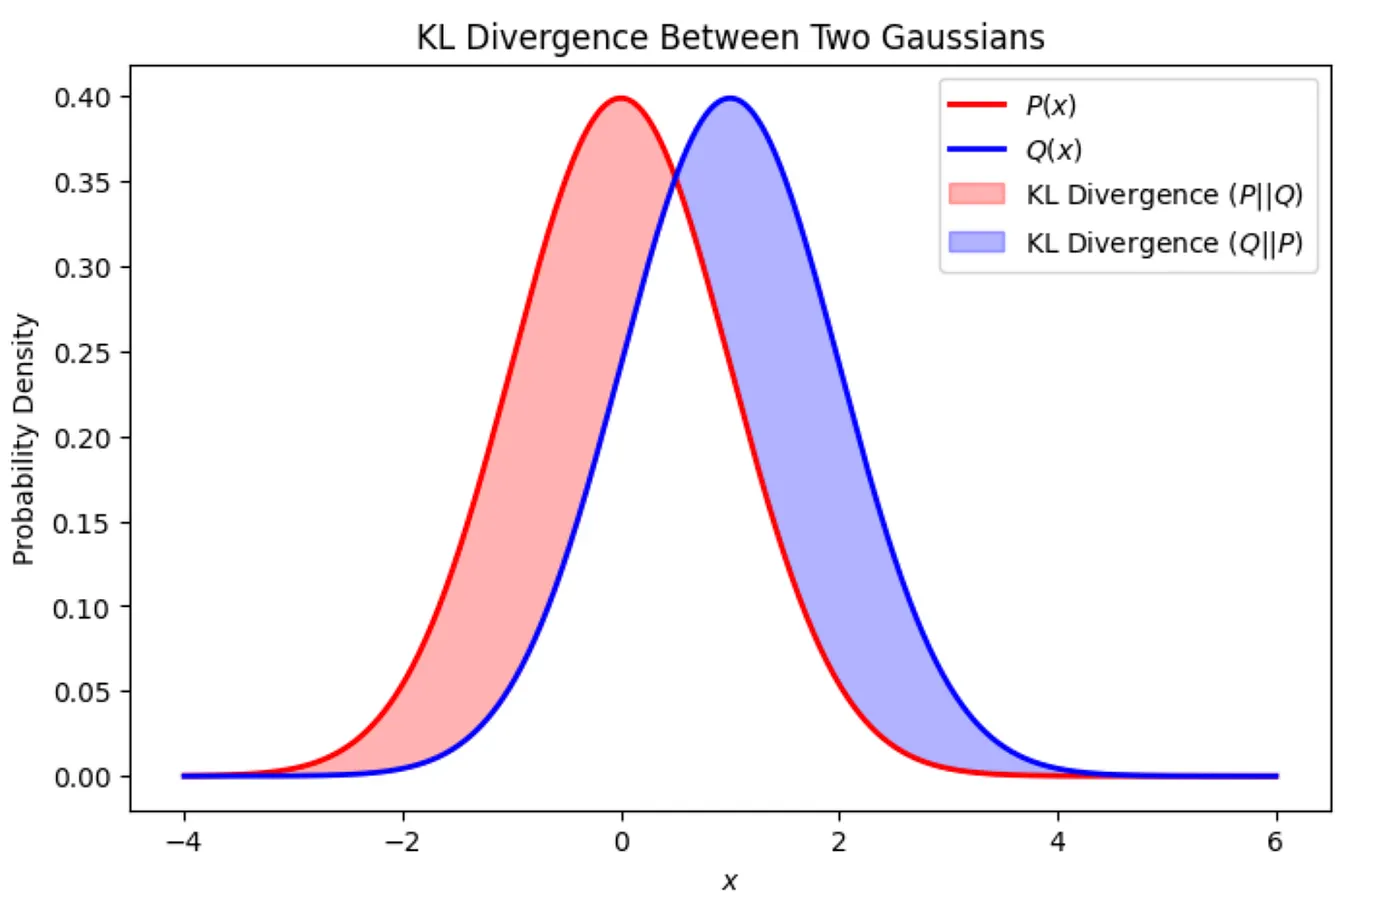

- **Purpose:** By forcing the latent distribution to be close to a standard normal, we ensure the latent space is smooth and continuous. This prevents the encoder from simply "memorizing" inputs as isolated points and allows us to sample random points from the latent space to generate new, meaningful images.
- **Mathematical Formulation:**
  The KL divergence between the learned distribution $q(\boldsymbol{z} \mid \boldsymbol{X})$ and the prior $p(\boldsymbol{z})$ is denoted as:
  $$D_{KL}\left(q(\boldsymbol{z} \mid \boldsymbol{X}) \parallel p(\boldsymbol{z})\right)$$

  For a VAE with a Gaussian latent distribution, the KL loss is calculated as:
  $$D_{KL}\left(q(\boldsymbol{z} \mid \boldsymbol{X}) \parallel p(\boldsymbol{z})\right) = -\frac{1}{2}\sum_{j=1}^{J} \left(1 + \log(\sigma_j^2) - \mu_j^2 - \sigma_j^2\right)$$
  where $J$ is the dimensionality of the latent space.

<a id="Total-Loss"></a>
### **Total Loss**
The total VAE loss is the sum of these two components:
$$\text{Total Loss} = \text{Reconstruction Loss} + \text{KL Loss}$$

<a id="Implementation-Details"></a>
### **Implementation Details**
In the code:
- `mean` represents the learned mean $\boldsymbol{\mu}$.
- `log_var` represents the logarithm of the variance $\log(\boldsymbol{\sigma}^2)$.

Since $\exp(\text{log\_var}) = \boldsymbol{\sigma}^2$, the formula is implemented as:
$$\text{KL Loss} = -\frac{1}{2}\sum_{j=1}^{J} \left(1 + \text{log\_var}_j - \text{mean}_j^2 - \exp(\text{log\_var}_j)\right)$$

In TensorFlow, this is implemented as:
```python
kl_loss = -0.5 * tf.reduce_mean(
    1 + log_var - tf.square(mean) - tf.exp(log_var)
)
```

**Note:** While the decoder only requires the sampled point $\boldsymbol{z}$ to reconstruct the image, the KL loss requires both the `mean` and `log_var` outputs from the encoder to calculate the divergence.


In [197]:
from tensorflow.keras import ops  # Keras 3 operations

# make loss function


# reconstruction_loss
def reconstruction_loss(y, y_hat):
    return tf.reduce_mean(tf.square(y - y_hat))


# Kullback–Leibler divergence encoder loss
def kl_loss(mu, log_var):
    # loss = -0.5 * tf.reduce_mean(1 + log_var - tf.square(mean) - tf.exp(log_var))
    kl = -0.5 * ops.mean(1 + log_var - ops.square(mu) - ops.exp(log_var))
    return kl


# add two losses
def vae_loss(y_true, y_hat, mu, log_var):
    return reconstruction_loss(y_true, y_hat) + (1 / (64 * 64)) * kl_loss(
        mean, log_var
    )

<a id="Putting-it-all-Together"></a>
## **Putting it all Together**


We combine the encoder and decoder to create the full VAE.

The encoder returns three values: `mean`, `log_var`, and `z`. The decoder only needs `z` to reconstruct an image, but the training loss also needs `mean` and `log_var` to calculate the KL loss.

In other words:

* `z` goes into the decoder.
* `mean` and `log_var` help train the latent space.
* The full VAE connects input image $\boldsymbol X$ to reconstructed image $\boldsymbol{\hat X}$.


In [198]:
# encoder returns mean and log variance of the normal distribution,
# and a sample point z
mean, log_var, z = encoder(encoder_input)

# decoder decodes the sample z
reconstructed = decoder(z)

model = Model(encoder_input, reconstructed, name="vae")
# loss = kl_loss(mean, log_var)
# model.add_loss(loss)
# model.summary()

<a id="Training-the-VAE"></a>
## **Training the VAE**

We now train the model. After each epoch, we input random latent points <code>z</code> into the decoder. As training improves, the decoder output should look more and more like handwritten digits.

We also plot the encoder's latent representations for the training data. Each point is colored by its digit label. As training improves, examples from similar digit classes should become more organized in the latent space.


Samples generated by decoder after 0 epoch(s): 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


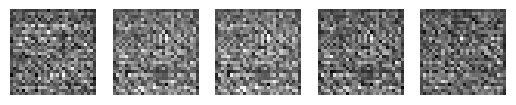

2D latent representations of the training data produced by encoder after 0 epoch(s): 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 497us/step


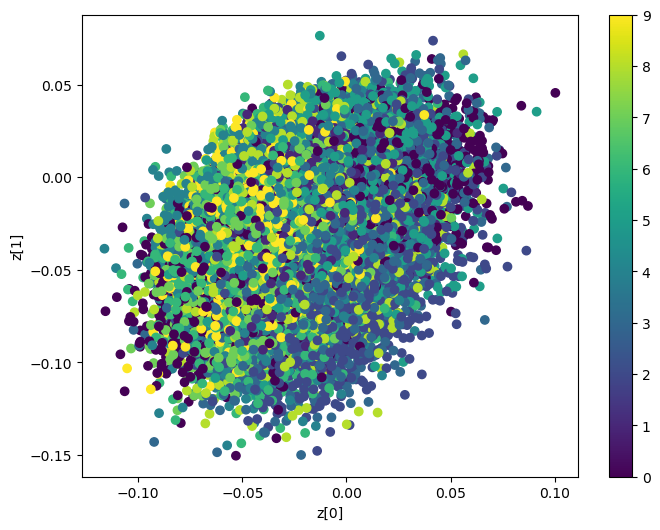

Epoch: 0 - Step: 599 - MSE loss: 0.06462531 - KL loss: 0.055246986
Samples generated by decoder after 1 epoch(s): 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


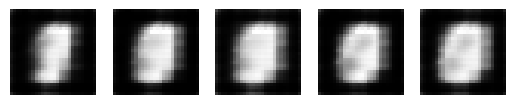

2D latent representations of the training data produced by encoder after 1 epoch(s): 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 504us/step


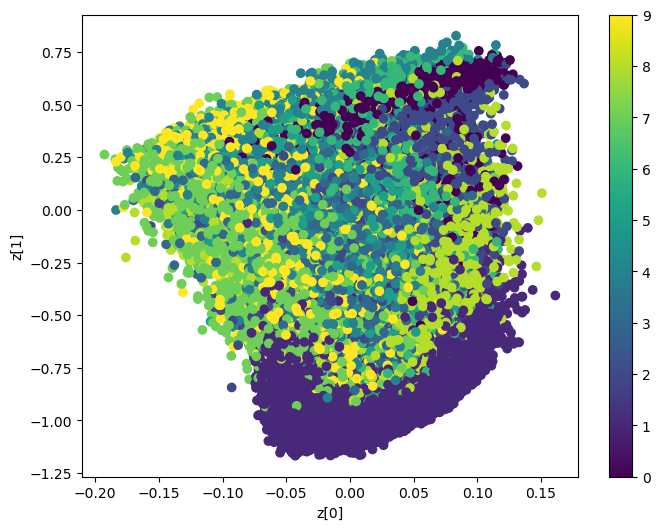

Epoch: 1 - Step: 599 - MSE loss: 0.064152405 - KL loss: 0.21566617
Samples generated by decoder after 2 epoch(s): 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


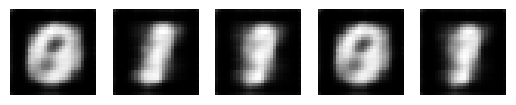

2D latent representations of the training data produced by encoder after 2 epoch(s): 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 533us/step


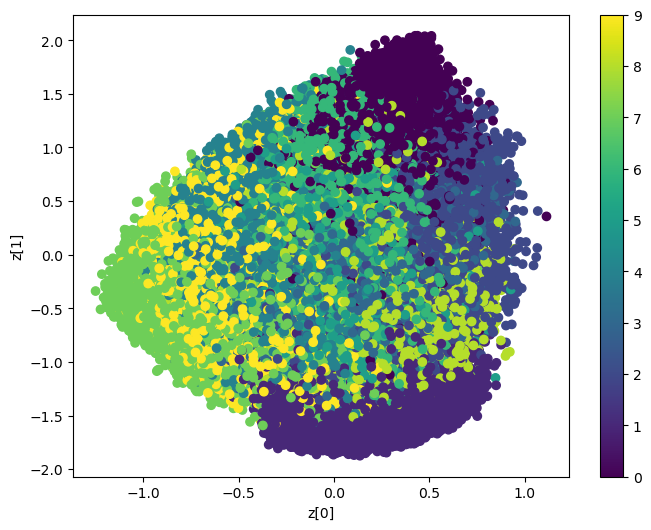

Epoch: 2 - Step: 599 - MSE loss: 0.06462852 - KL loss: 0.3853039
Samples generated by decoder after 3 epoch(s): 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


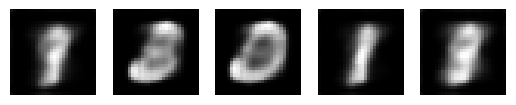

2D latent representations of the training data produced by encoder after 3 epoch(s): 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 483us/step


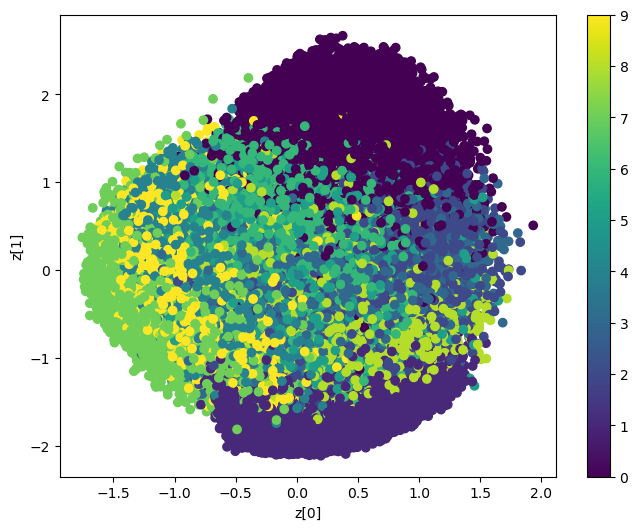

Epoch: 3 - Step: 599 - MSE loss: 0.06208474 - KL loss: 0.39537337
Samples generated by decoder after 4 epoch(s): 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


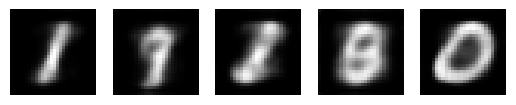

2D latent representations of the training data produced by encoder after 4 epoch(s): 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 545us/step


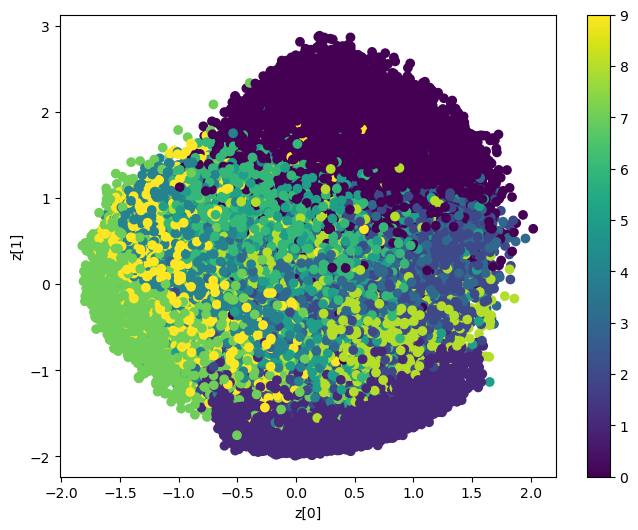

Epoch: 4 - Step: 599 - MSE loss: 0.06174686 - KL loss: 0.48137772


In [199]:
# loss
mse_losses = []
kl_losses = []
# optimizer
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002, beta_1=0.5, beta_2=0.999
)
epochs = 5

for epoch in range(epochs):

    print(f"Samples generated by decoder after {epoch} epoch(s): ")

    # random noise
    z = tf.random.normal(
        shape=(
            5,
            latent_dim,
        )
    )

    # input random noise into the decoder
    xhat = decoder.predict(z)

    # plot the decoder output
    plt.figure()
    for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(xhat[i, :, :, 0], cmap="gray")
        plt.axis("off")
    plt.show()

    print(
        f"2D latent representations of the training data produced by encoder after {epoch} epoch(s): "
    )
    plot_label_clusters(encoder, X_train, y_train)

    # training steps
    for step, training_batch in enumerate(dataset.batch(100)):
        with tf.GradientTape() as tape:
            # Get all encoder outputs AND the final reconstruction in ONE pass
            m, lv, sampled_z = encoder(training_batch)
            reconstructed = decoder(sampled_z)

            # 1. Reconstruction Loss
            y_true = tf.reshape(training_batch, shape=[-1])
            y_pred = tf.reshape(reconstructed, shape=[-1])
            mse_loss = reconstruction_loss(y_true, y_pred)

            # 2. KL Loss (Manual calculation for Keras 3)
            kl_loss_val = -0.5 * tf.reduce_mean(
                1 + lv - tf.square(m) - tf.exp(lv)
            )

            # 3. Total loss
            train_loss = 0.01 * kl_loss_val + mse_loss

            # Calculate gradients for BOTH encoder and decoder
            grads = tape.gradient(train_loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

            # Store for plotting
            mse_losses.append(mse_loss.numpy())
            kl_losses.append(kl_loss_val.numpy())

    # print("Epoch: %s - Step: %s - MSE loss: %s - KL loss: %s" % (epoch, step, mse_loss.numpy(), kl.numpy()))
    # Fixed print statement:
    print(
        "Epoch: %s - Step: %s - MSE loss: %s - KL loss: %s"
        % (epoch, step, mse_loss.numpy(), kl_loss_val.numpy())
    )

We plot the reconstruction loss and Kullback–Leibler divergence against the number of training iterations, we can see that they are both decreasing.


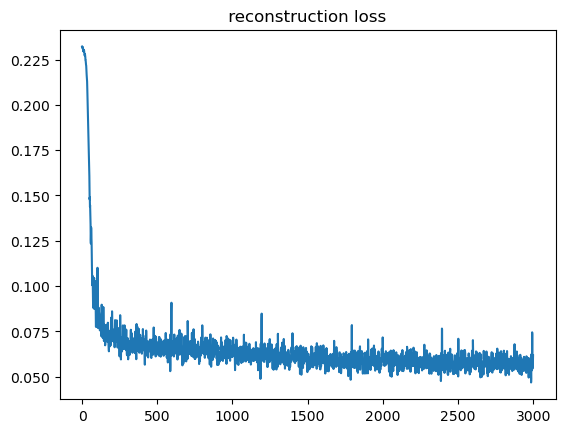

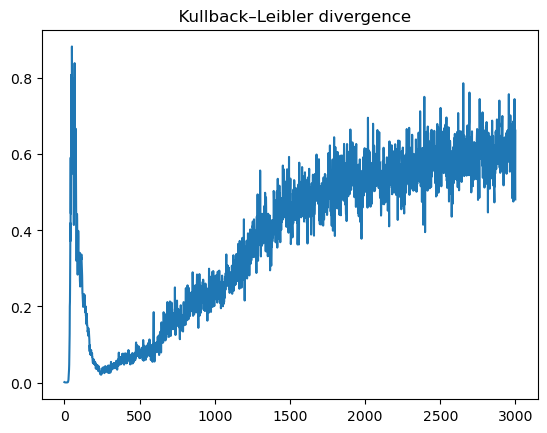

In [200]:
plt.plot(mse_losses)
plt.title(" reconstruction loss ")
plt.show()
plt.plot(kl_losses)
plt.title("  Kullback–Leibler divergence")
plt.show()

Now that our VAE has been trained, we can use its decoder network to generate some samples. Let's see if our decoder can do a good job in generating artificial images that look like digits!


In [201]:
xhat = decoder.predict(z)
xhat.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


(5, 28, 28, 1)

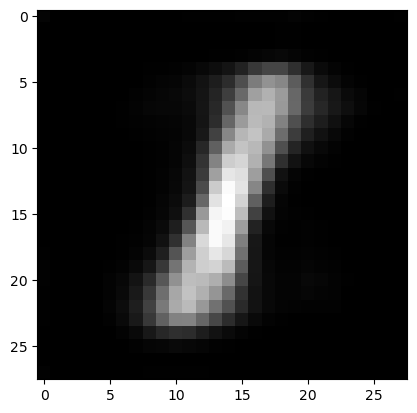

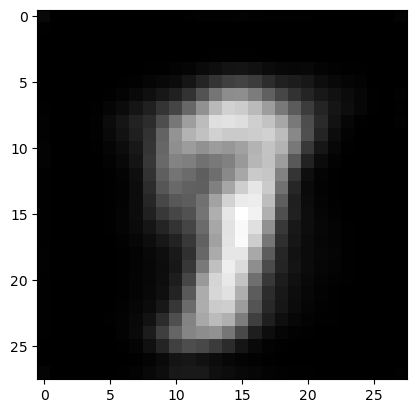

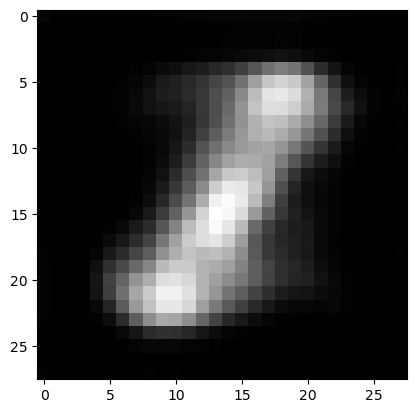

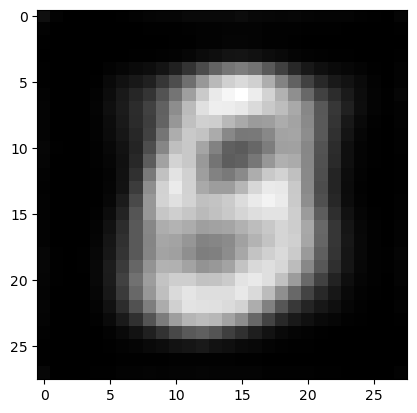

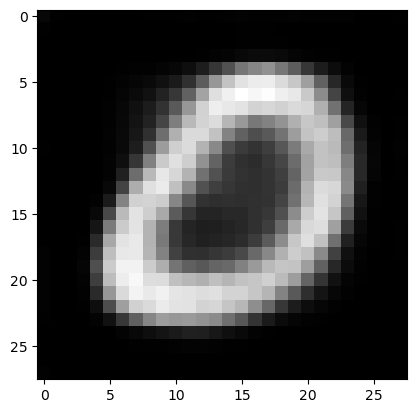

In [202]:
for i in range(5):
    plt.imshow(xhat[i, :, :, 0], cmap="gray")
    plt.show()

We can also visualize the final latent representations of the training data produced by the trained encoder on a 2D plot, colored by classes.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 520us/step


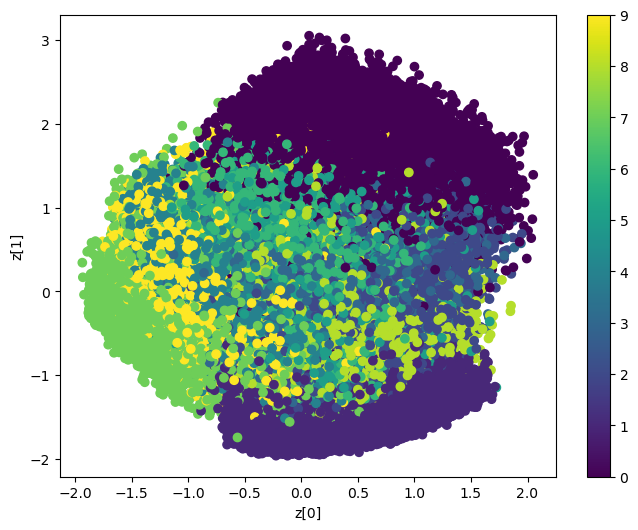

In [203]:
plot_label_clusters(encoder, X_train, y_train)

<a id="Modified-Version"></a>
## **Modified Version**

In [204]:
from tensorflow.keras import layers

latent_dim = 2


class Sampling(layers.Layer):
    def call(self, inputs):
        mean, log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(mean))
        return mean + tf.exp(0.5 * log_var) * epsilon


# Encoder
encoder_input = keras.Input(shape=(28, 28, 1), name="encoder_input")

x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(
    encoder_input
)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)

mean = layers.Dense(latent_dim, name="mean")(x)
log_var = layers.Dense(latent_dim, name="log_var")(x)
z = Sampling(name="z")([mean, log_var])

encoder = keras.Model(encoder_input, [mean, log_var, z], name="encoder")


# Decoder
decoder_input = keras.Input(shape=(latent_dim,), name="decoder_input")

x = layers.Dense(7 * 7 * 64, activation="relu")(decoder_input)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(
    x
)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(
    x
)
decoder_output = layers.Conv2DTranspose(
    1, 3, activation="sigmoid", padding="same"
)(x)

decoder = keras.Model(decoder_input, decoder_output, name="decoder")

VAELossLayer lets you put the VAE loss inside the model.
Keras then handles gradient descent automatically with compile() and fit().

In [205]:
class VAELossLayer(keras.layers.Layer):

    ## Stores how much importance to give the KL loss term in the total loss
    def __init__(self, kl_weight=0.01, **kwargs):
        super().__init__(**kwargs)
        self.kl_weight = kl_weight

    def call(self, inputs):
        original, reconstruction, mean, log_var = inputs

        ## This measures how different the reconstructed image is from the original image.
        reconstruction_loss = keras.ops.mean(
            keras.ops.sum(
                keras.ops.square(original - reconstruction), axis=(1, 2, 3)
            )
        )

        ## This measures how different the learned latent distribution is from a standard normal distribution.
        kl_loss = -0.5 * keras.ops.mean(
            keras.ops.sum(
                1 + log_var - keras.ops.square(mean) - keras.ops.exp(log_var),
                axis=1,
            )
        )

        ## Total loss:
        total_loss = reconstruction_loss + self.kl_weight * kl_loss

        ## When training this model, include this loss.
        self.add_loss(total_loss)

        return reconstruction

A normal loss function in `model.compile(loss=...)` usually only sees: y_true and y_pred

But KL loss needs mean and log_var, which are inside the model. A custom `VAELossLayer` layer can access all of them. This custom layer is not used to “learn features” like `Dense`. It is used to attach the VAE loss to the model.

In [206]:
## Creates the input for the full VAE model.
## one input image has shape: (28, 28, 1)
vae_input = keras.Input(shape=(28, 28, 1), name="vae_input")

## Passes the input image through the encoder.
mean, log_var, z = encoder(vae_input)

## Passes z into the decoder to rebuilt image
reconstruction = decoder(z)

## sends four things into the custom loss layer:
vae_output = VAELossLayer(kl_weight=0.01)(
    [vae_input, reconstruction, mean, log_var]
)

## Creates the full model:
vae = keras.Model(vae_input, vae_output, name="vae")

In [207]:
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0002))

vae.fit(X_train, epochs=5, batch_size=100)

Epoch 1/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 63.9325
Epoch 2/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 45.2463
Epoch 3/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 40.8968
Epoch 4/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 39.3885
Epoch 5/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 38.2973


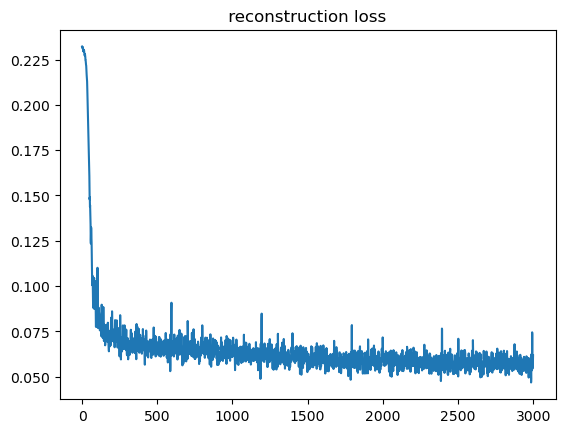

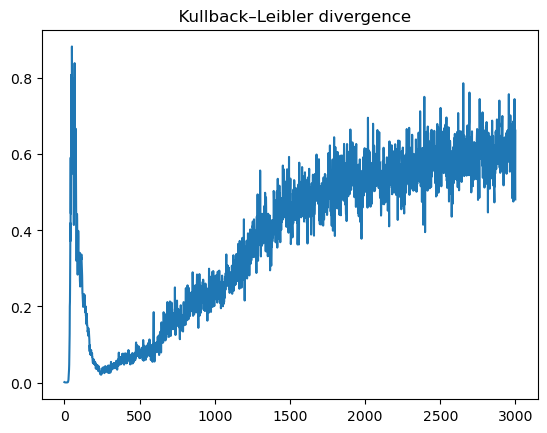

In [208]:
plt.plot(mse_losses)
plt.title(" reconstruction loss ")
plt.show()
plt.plot(kl_losses)
plt.title("  Kullback–Leibler divergence")
plt.show()

## **Authors**


[Joseph Santarcangelo](https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01) has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.

[Roxanne Li](https://www.linkedin.com/in/roxanne-li/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01) is a Data Science intern at IBM Skills Network, entering level-5 study in the Mathematics & Statistics undergraduate Coop program at McMaster University.


## **Change Log**


| Date (YYYY-MM-DD) | Version | Changed By | Change Description      |
| ----------------- | ------- | ---------- | ----------------------- |
| 2022-09-14        | 0.1     | Joseph S.  | Created Lab             |
| 2022-09-19        | 0.1     | Roxanne Li | Reviewed and edited lab |
| 2026-05-28     | 0.2     | Su Wu| Documentation and script edits   |


Copyright © 2022 IBM Corporation. All rights reserved.
